# Trabajo Práctico 1: Un clima estresante
## Alumnos: Córdoba Lucía, Gagliardi Lara y Sánchez Joaquín

El registro de datos meteorológicos es fundamental para la comprensión y predicción de las condiciones atmosféricas, ya que estas influyen en diversos aspectos de la vida humana, como la agricultura, la gestión de recursos naturales, la planificación ambiental, la prevención de desastres y la investigación científica.

En Australia existe una base de datos en línea denominada SILO (Scientific Information for Land Owners), que proporciona información climática sobre variables como temperatura, precipitación, humedad relativa, evaporación y radiación solar. A partir de estos datos pueden desarrollarse estrategias para adaptarse a los cambios climáticos.

Los datos analizados corresponden a registros diarios proporcionados por SILO para las coordenadas (-27.9927, 152.6906) durante el período 2019-2023.

### Carga de módulos

In [1]:
import polars as pl

import pyprojroot

import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from plotnine import aes, geom_line, geom_point, ggplot, scale_x_continuous, labs, theme_bw, theme, element_text, element_blank, element_rect, facet_wrap, geom_density

import math

ROOT = pyprojroot.here()

### Carga de datos

En primer lugar, cargamos los datos meteorológicos de la ciudad rural en los años 2019 a 2023.

In [60]:
atmosfera19 = pl.read_csv(ROOT / "Datos" / "2019" / "atmosfera.csv")
energia19 = pl.read_csv(ROOT / "Datos" / "2019" / "energia.csv")
lluvias19 = pl.read_csv(ROOT / "Datos" / "2019" / "lluvias.csv")

atmosfera20 = pl.read_csv(ROOT / "Datos" / "2020" / "atmosfera.csv")
energia20 = pl.read_csv(ROOT / "Datos" / "2020" / "energia.csv")
lluvias20 = pl.read_csv(ROOT / "Datos" / "2020" / "lluvias.csv")

atmosfera21 = pl.read_csv(ROOT / "Datos" / "2021" / "atmosfera.csv")
energia21 = pl.read_csv(ROOT / "Datos" / "2021" / "energia.csv")
lluvias21 = pl.read_csv(ROOT / "Datos" / "2021" / "lluvias.csv")

atmosfera22 = pl.read_csv(ROOT / "Datos" / "2022" / "atmosfera.csv")
energia22 = pl.read_csv(ROOT / "Datos" / "2022" / "energia.csv")
lluvias22 = pl.read_csv(ROOT / "Datos" / "2022" / "lluvias.csv")

atmosfera23 = pl.read_csv(ROOT / "Datos" / "2023" / "atmosfera.csv")
energia23 = pl.read_csv(ROOT / "Datos" / "2023" / "energia.csv")
lluvias23 = pl.read_csv(ROOT / "Datos" / "2023" / "lluvias.csv")

Luego, unimos los datos en una única base de datos.

In [61]:
datos2019 = atmosfera19.join(energia19, on = "fecha", how = "inner").join(lluvias19, on = "fecha", how = "inner")
datos2020 = atmosfera20.join(energia20, on = "fecha", how = "inner").join(lluvias20, on = "fecha", how = "inner")
datos2021 = atmosfera21.join(energia21, on = "fecha", how = "inner").join(lluvias21, on = "fecha", how = "inner")
datos2022 = atmosfera22.join(energia22, on = "fecha", how = "inner").join(lluvias22, on = "fecha", how = "inner")
datos2023 = atmosfera23.join(energia23, on = "fecha", how = "inner").join(lluvias23, on = "fecha", how = "inner")

datos = pl.concat([datos2019, datos2020, datos2021, datos2022, datos2023], how = "vertical")

Realizamos una breve inspección de los datos para conocer su estructura.

In [62]:
observaciones_total = datos.shape[0]
observaciones_2019 = datos2019.shape[0]
observaciones_2020 = datos2020.shape[0]
observaciones_2021 = datos2021.shape[0]
observaciones_2022 = datos2022.shape[0]
observaciones_2023 = datos2023.shape[0]

observaciones_total, observaciones_2019, observaciones_2020, observaciones_2021, observaciones_2022, observaciones_2023

(1826, 365, 366, 365, 365, 365)

En el conjunto de datos hay 1826 observaciones. En los años 2019, 2021, 2022 y 2023 se registraron 365 observaciones mientras que en el año 2020 hay 366 observaciones debido a que este fue un año bisiesto.

In [5]:
datos.null_count()

fecha,t_min,t_max,hr_t_min,hr_t_max,evaporación,radiación,lluvia
u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0


En ninguna de las variables se presentaron valores faltantes.

A continuación analizamos la cantidad total de lluvia caída en la zona y cuánto se corresponde a cada año.

In [6]:
lluvia_total = datos["lluvia"].sum()
lluvia_total

4327.799999999999

In [7]:
# Agregamos una columna con el año
datos = datos.with_columns(
    pl.col("fecha")
    .str.to_date()
    .dt.year()
    .alias("anio")
)

lluvia_por_anio = (
    datos
    .group_by("anio")
    .agg(
    pl.col("lluvia")
    .sum()
    .alias("lluvia_total")
    )
    .sort("anio")
)

lluvia_por_anio

anio,lluvia_total
i32,f64
2019,346.6
2020,811.6
2021,950.4
2022,1476.2
2023,743.0


La cantidad total de lluvia registrada en la zona rural fue de 4327.79 milímetros (mm). El año 2019 presentó las menores precipitaciones, con 346.6 mm, mientras que 2022 registró la mayor cantidad de lluvia, con 1476.2 mm. Este aumento estuvo asociado al fenómeno climático llamado Dipolo Negativo del Océano Índico, el cual provocó intensas inundaciones.

Para visualizar la información anterior, realizamos un gráfico de barras.

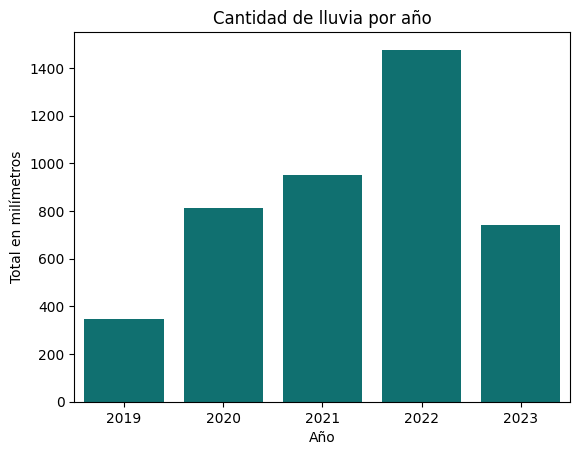

In [8]:
sns.barplot(
    x = "anio", 
    y = "lluvia_total", 
    color = "teal",
    data = lluvia_por_anio
    )
plt.title(
    "Cantidad de lluvia por año"
)

plt.xlabel("Año")
plt.ylabel("Total en milímetros");

La cantidad total de lluvia por año presenta un aumento desde el año 2019, alcanzando su punto máximo en el año 2022 con aproximadamente 1500 mm acumulados. En el año 2023, se produjo una disminución en el total de lluvias, con un valor menor al del año 2020.

Después, graficamos la cantidad de lluvia por mes y año a través de un gráfico de líneas.

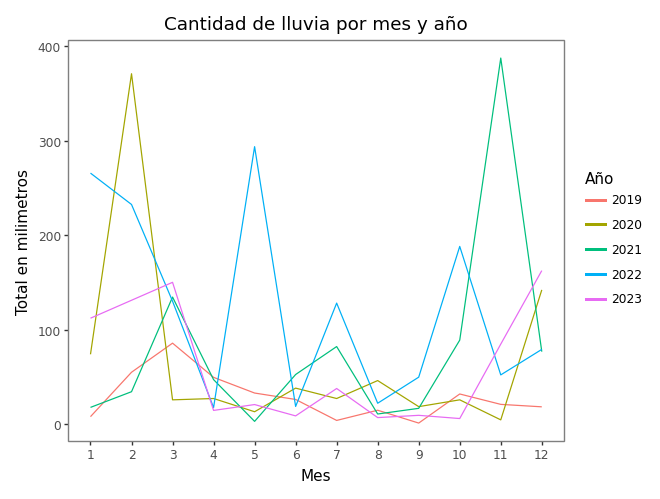

In [9]:
# Agregamos una columna con el mes
datos = datos.with_columns(
    pl.col("fecha")
    .str.to_date()
    .dt.month()
    .alias("mes")
)

# Creamos una base con el total de lluvia por mes y año
datos_agrupado_anio_mes = (
    datos
    .group_by("anio", "mes")
    .agg(
        pl.col("lluvia")
        .sum()
        .alias("total")
        )
    .sort(["anio", "mes"])
)

grafico = (
    ggplot(datos_agrupado_anio_mes) +  
    aes(x = "mes", y = "total", color = "factor(anio)") + 
    geom_line() +
    scale_x_continuous(breaks = range(1, 13)) +
    theme_bw() + 
    labs(
        title = "Cantidad de lluvia por mes y año",
        x = "Mes",
        y = "Total en milimetros",
        color = "Año"
    ) +
    theme(
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
    )
)

grafico

El gráfico muestra que el total de lluvia  mensual (mm) no presenta el mismo comportamiento a lo largo de los años. En general, existe una tendencia a registrar mayores precipitaciones en los primeros (enero-marzo) y últimos meses del año (octubre-diciembre), mientras que en los meses intermedios tiende a disminuir.

Los años 2019 y 2023 presentan comportamientos similares, caracterizados por un aumento de las precipitaciones en marzo y valores moderados durante el resto del año, a excepción de diciembre de 2023, cuando las precipitaciones fueron mayores. En el año 2020, la mayor cantidad de lluvia se registró en febrero, seguido por diciembre, mientras que en el resto de los meses las precipitaciones se mantuvieron relativamente estables. 

Por otro lado, los años 2021 y 2022 presentan una mayor variabilidad mensual, con varios meses que registran precipitaciones elevadas. En particular, en 2021 se destaca un pico muy marcado en noviembre, mientras que en 2022 sobresalen los aumentos registrados en mayo, julio y octubre.

Para analizar cómo varía las temperaturas máximas y mínimas a lo largo del tiempo graficamos el promedio de las temperaturas para cada mes en todos los años.

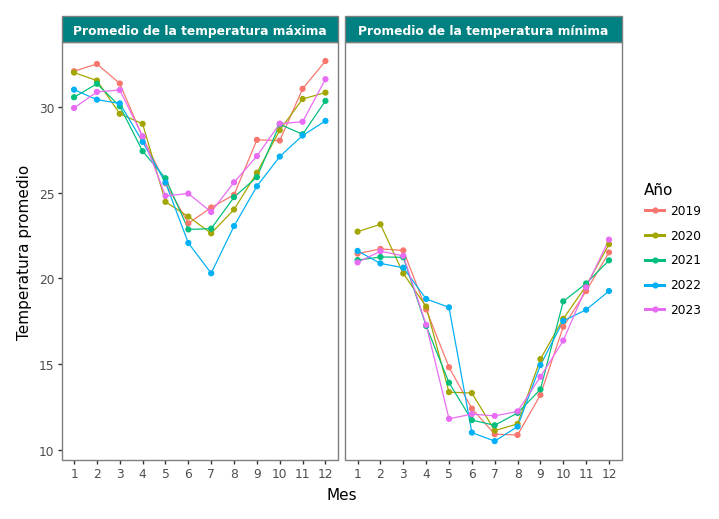

In [10]:
# Creamos una base con la temperatura mínima y máxima promedio para cada mes de cada año
datos_temp_mes = (
    datos
    .group_by("mes", "anio")
    .agg(
        pl.col("t_min")
        .mean()
        .alias("Promedio de la temperatura mínima"), 

        pl.col("t_max")
        .mean()
        .alias("Promedio de la temperatura máxima")
        )
        .sort("anio", "mes")
)

# Para poder graficar ambas temperaturas promedios usando facet_wrap() es necesario que 
# haya una columna que indique si la temperatura es máxima o mínima por lo que es necesario
# que ambas temperaturas promedios se encuentren en una misma columna, es decir, hay que 
# pasarlo a formato largo

datos_temp_mes_largo = (
    datos_temp_mes
    .unpivot(
        index = ["mes", "anio"], # index hace que esas columnas no se modifiquen
        on = ["Promedio de la temperatura mínima", "Promedio de la temperatura máxima"], # columnas a modificar
        variable_name = "tipo",
        value_name = "promedio_t"
    )
)

(
ggplot(datos_temp_mes_largo) +
aes(
    x = "mes",
    y = "promedio_t",
    color = "factor(anio)"
    ) +
geom_line() +
geom_point() +
facet_wrap("~tipo") +
scale_x_continuous(breaks = range(1, 13)) +
theme_bw() +
labs(
    x = "Mes",
    y = "Temperatura promedio",
    color = "Año"
    ) +
theme(    
    figure_size=(7, 5),
    panel_grid_minor = element_blank(),
    panel_grid_major = element_blank(),
    strip_background = element_rect(fill = "teal", color = None),
    strip_text = element_text(color = "white", weight = "bold")
    )
)

Las temperaturas mínimas y máximas promedio presentan un comportamiento similar a lo largo de los años analizados. Los valores más elevados se registran al inicio y al final del año, coincidiendo con los meses de verano en la región, mientras que, durante los meses invernales se observan las temperaturas promedio más bajas.

También analizamos la asociación entre la temperatura mínima y máxima a través de un gráfico de dispersión.

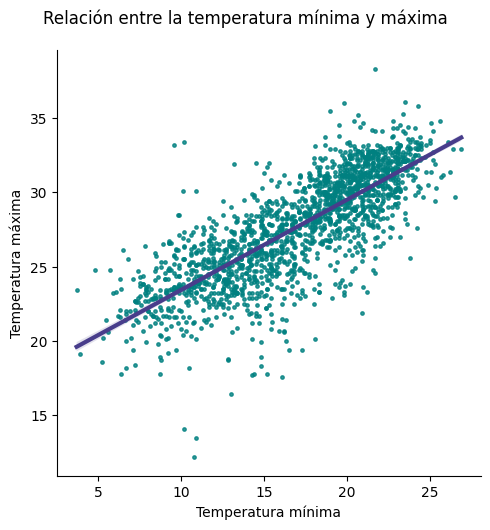

In [11]:
g = sns.lmplot(
    data = datos, 
    x = "t_min", 
    y = "t_max",
    scatter_kws = {"s": 6, "color": "teal"},
    line_kws = {"color": "darkslateblue", "linewidth": 3}
)

g.set_xlabels("Temperatura mínima")
g.set_ylabels("Temperatura máxima")
g.fig.suptitle(
    "Relación entre la temperatura mínima y máxima",
    y=1.05
);

Las temperaturas mínima y máxima presentan una relación positiva y aproximadamente lineal. Es decir, a medida que aumenta la temperatura mínima, también tiende a incrementar la temperatura máxima.

Luego, calculamos la amplitud térmica y analizamos su comportamiento a nivel global y a lo largo del tiempo.

In [12]:
# Agregamos la amplitud térmica al conjunto de datos
datos = datos.with_columns(
    amplitud_termica = pl.col("t_max") - pl.col("t_min")
)

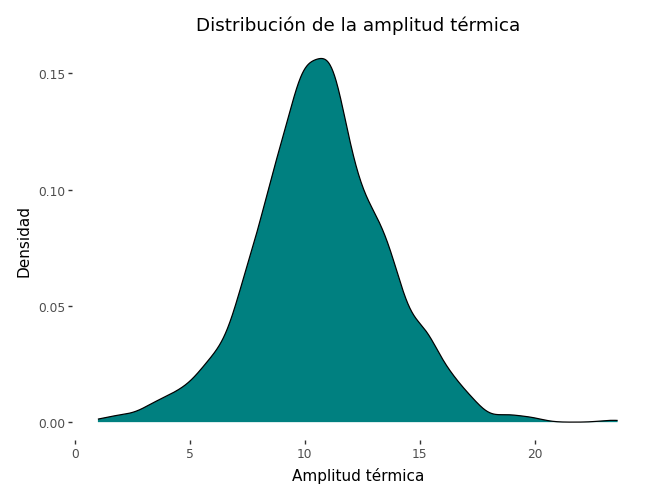

In [13]:
# Globalmente
(
ggplot(datos) + 
geom_density(
    aes("amplitud_termica"),
    fill = "teal"
    ) + 
labs(
    x = "Amplitud térmica",
    y = "Densidad",
    title = "Distribución de la amplitud térmica"
    ) + 
theme(    
    panel_grid_minor = element_blank(),
    panel_grid_major = element_blank(),
    panel_background = element_blank()
    )
)


En general, la amplitud térmica varía entre los 5 y 18 grados. Se aprecia una leve asimetría a la derecha.

A continuación, analizamos el comportamiento de la amplitud térmica a través de los años.

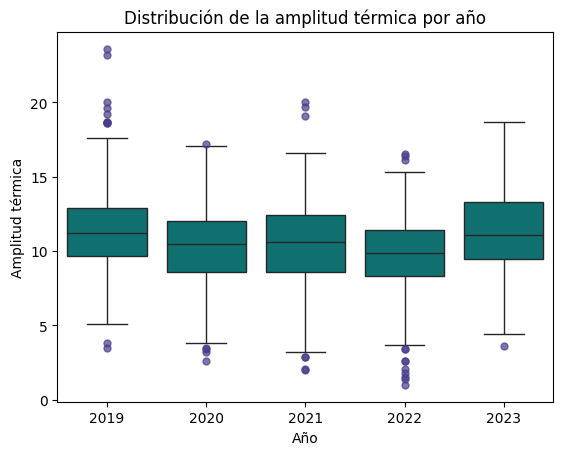

In [14]:
# a lo largo del tiempo
g = sns.boxplot(
    x = "anio", 
    y = "amplitud_termica", 
    color = "teal",
    data = datos,
    flierprops={
    "marker": "o",
    "markerfacecolor": "darkslateblue",
    "markeredgecolor": "darkslateblue",
    "markersize": 5,
    "alpha": 0.7
    })
g.set_xlabel("Año")
g.set_ylabel("Amplitud térmica")
g.set_title("Distribución de la amplitud térmica por año");

Para los años analizados, la amplitud térmica presenta valores similares en términos de mediana y variabilidad. Sin embargo, en el año 2023 se observan valores ligeramente superiores respecto de los años anteriores. Además, en todos los años se registran valores atípicos, tanto bajos como altos, aunque en el año 2022 se observa una mayor presencia de amplitudes térmicas muy bajas.

Analizamos la asociación entre la amplitud térmica y la temperatura mínima, máxima y el total de precipitaciones.

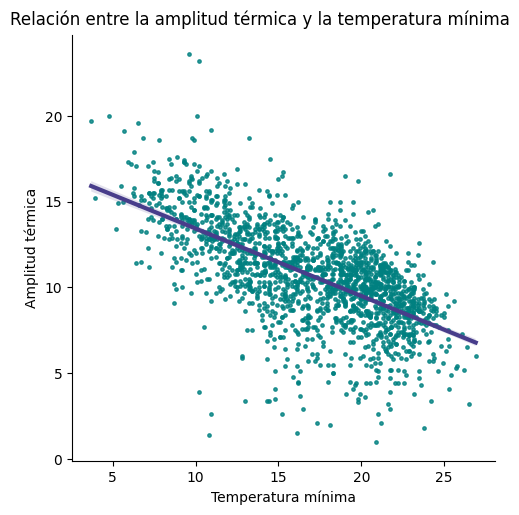

In [15]:
g = sns.lmplot(
    data = datos,
    x = "t_min",
    y = "amplitud_termica",
    scatter_kws = {"s": 6, "color": "teal"},
    line_kws = {"color": "darkslateblue", "linewidth": 3}
)

g.set_xlabels("Temperatura mínima")
g.set_ylabels("Amplitud térmica")

g.fig.suptitle(
    "Relación entre la amplitud térmica y la temperatura mínima",
    y = 1.02
);


In [16]:
datos.select(
    pl.corr("t_min", "amplitud_termica")
)

t_min
f64
-0.635425


La amplitud térmica se relaciona con la temperatura mínima de forma aproximadamente lineal, de manera que a medida que la temperatura mínima aumenta, la amplitud térmica disminuye.

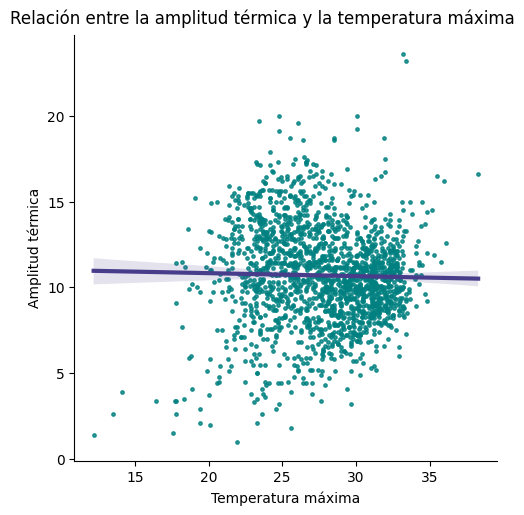

In [17]:
g = sns.lmplot(
    data = datos, 
    x = "t_max", 
    y = "amplitud_termica",
    scatter_kws = {"s": 6, "color": "teal"},
    line_kws = {"color": "darkslateblue", "linewidth": 3}
)

g.set_xlabels("Temperatura máxima")
g.set_ylabels("Amplitud térmica")

g.fig.suptitle(
    "Relación entre la amplitud térmica y la temperatura máxima",
    y = 1.02
);

In [39]:
datos.select(
    pl.corr("amplitud_termica", "t_max")
)

amplitud_termica
f64
-0.021824


No se observa una relación entre la amplitud térmica con la temperatura máxima observada.

Para analizar la relación entre la amplitud térmica y el total de lluvia, se aplicó una transformación logarítmica a la variable precipitación, ya que esta presenta una alta dispersión en sus valores.

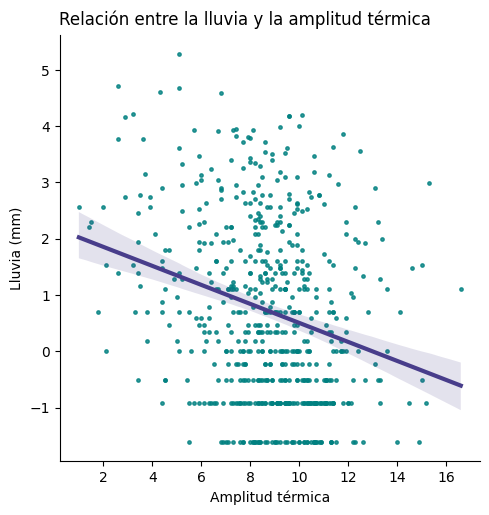

In [18]:
# Nos quedamos con los días en los que se registraron lluvias
datos_con_lluvia = datos.filter(pl.col("lluvia") != 0)

# Utilizamos la escala logarítmica para una mejor visualización
datos_con_lluvia = datos_con_lluvia.with_columns(
    pl.col("lluvia").log().alias("log_lluvia")
)

g = sns.lmplot(
    data = datos_con_lluvia, 
    x = "amplitud_termica",
    y = "log_lluvia", 
    scatter_kws = {"s": 6, "color": "teal"},
    line_kws = {"color": "darkslateblue", "linewidth": 3}
)

g.set_xlabels("Amplitud térmica")
g.set_ylabels("Lluvia (mm)")

g.fig.suptitle(
    "Relación entre la lluvia y la amplitud térmica",
    y = 1.02
);

In [19]:
datos.select(
    pl.corr("lluvia", "amplitud_termica")
)

lluvia
f64
-0.267443


No se ve una relación clara entre la cantidad de lluvia y la amplitud térmica.

Para analizar la radiación, calculamos la radiación media para cada mes y obtenemos cúales son los que presentan valores mayores.

In [19]:
(
datos
.group_by("mes")
.agg(
    pl.col("radiación")
    .mean()
    .alias("prom_rad")
    )
.sort("prom_rad", descending = True)
)

mes,prom_rad
i8,f64
12,25.363226
1,24.005806
11,23.785333
2,22.77305
10,22.729032
…,…
4,17.395333
8,17.171613
5,14.414839


Los meses de verano presentan radiación promedio mayor que el resto, con valores alrededor de los 23 (MJ / m²).

Además, buscamos en qué mes a lo largo de los 5 años se observó el mayor nivel de evaporación.

In [20]:
(
datos
.group_by("mes")
.agg(
    pl.col("evaporación")
    .sum()
    )
.sort("evaporación")
.tail(1)
)

mes,evaporación
i8,f64
12,1056.7


In [21]:
(
datos
.group_by("anio", "mes")
.agg(
    pl.col("evaporación")
    .sum()
    )
.sort("evaporación")
.tail(1)
)

anio,mes,evaporación
i32,i8,f64
2019,12,274.2


Al considerar los 5 años en conjunto, se obtuvo que el mes de diciembre presenta mayor evaporación total, con 1056.7 (mm). Si analizamos nivel de evaporación total por mes para cada año por separado, en diciembre de 2019 se registró el mayor valor (274.2 mm).

### Días de estrés

Los “días de estrés” se refieren a días en que las condiciones ambientales son desfavorables para el crecimiento óptimo de los cultivos. Un factor que determina el nivel de estrés es la temperatura ya que cuando estas son extremas, pueden causar estrés térmico en los cultivos. 

A continuación, clasificamos los días de estrés considerando la temperatura máxima. Se establece una temperatura de referencia de 32 grados centígrados.

In [22]:
# Creamos una columna indicando si se considera un día de estrés o no
datos_estres = (
    datos.with_columns(
    pl.when(pl.col("t_max") >= 32)
    .then(pl.lit(1))
    .otherwise(pl.lit(0))
    .alias('estres')
    )
)

Obtenemos el total de días de estrés ocurridos entre el 14-10-2019 y el 03-12-2019.

In [23]:
(
datos_estres
.filter(pl.col("fecha") >= "2019-10-14", pl.col("fecha") <= "2019-12-03")["estres"]
.value_counts()
)

estres,count
i32,u32
1,11
0,40


En el período analizado hubo 11 días cuya temperatura máxima excedió los 32ºC.

Calculamos la cantidad de días de estrés térmico por mes a lo largo de los 5 años y lo visualizamos en un gráfico de línea.

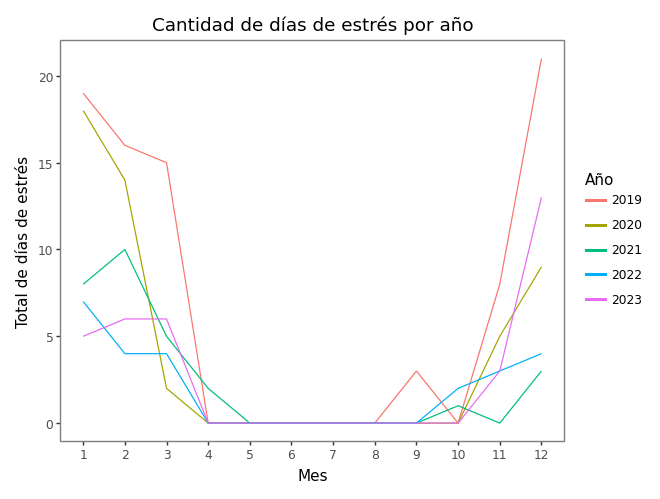

In [24]:
# Creamos una base con los días de estrés para cada mes y año
datos_estres_agrupado_mes_anio = (
    datos_estres
    .group_by("mes", "anio")
    .agg(
        pl.col("estres")
        .sum()
        .alias("total")
    )
    .sort("total", descending = True)
)

grafico = (
    ggplot(datos_estres_agrupado_mes_anio) +  
    aes(x = "mes", y = "total", color = "factor(anio)") + 
    geom_line() +
    scale_x_continuous(breaks = range(1, 13)) +
    theme_bw() + 
    labs(
        title = "Cantidad de días de estrés por año",
        x = "Mes",
        y = "Total de días de estrés",
        color = "Año"
    ) +
    theme(
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
    )
)

grafico

Los días de estrés ocurren con mayor frecuencia en los meses de verano, es decir, entre noviembre y marzo. En los 5 años analizados no ocurrieron días de estrés en los meses de mayo a agosto.

Elaboramos una función que, dado el conjunto de datos, una fecha de inicio y una fecha de fin, devuelve la cantidad de días de estrés térmico dentro del rango de fechas indicado.

In [30]:
def calcular_dias_estres(datos, fecha, temperatura, inicio, fin):

    """ 
    Cálculo de la cantidad de días de éstres ocurridos en un período:
        datos: dataframe con un la información a analizar
        fecha: nombre de la columna que contiene la fecha del registro
        temperatura: nombre de la columna que se considerará para clasificar los días de estrés
        inicio: fecha de inicio del período (String 'YYYY-MM-DD')
        fin: fecha del fin del período (String 'YYYY-MM-DD')
    """

    formato = "%Y-%m-%d"

    try: # prueba si hay un error al pasar el str al formato de la fecha
        datetime.datetime.strptime(inicio, formato)
        datetime.datetime.strptime(fin, formato)

    except ValueError:  # si hay algún ValueError se muestra el mensaje
        raise ValueError("Las fechas deben ingresarse en el formato 'YYYY-MM-DD'.")

    if inicio < datos[fecha].min() or fin > datos[fecha].max():
        raise ValueError(
            f"Fechas fuera de rango. La base de datos contiene registros desde {datos[fecha].min()} hasta {datos[fecha].max()}."
        )

    suma_estres = (
        datos
        .filter(
            pl.col(fecha).is_between(pl.lit(inicio), pl.lit(fin))
        )
        .with_columns(
            pl.when(pl.col(temperatura) >= 32)
            .then(pl.lit(1))
            .otherwise(pl.lit(0))
            .alias("estres")
        )
        .select(
            pl.col("estres").sum()
        )
        .item()
    )

    return f"Entre la fecha {inicio} y la fecha {fin} hubo {suma_estres} días de estrés."

In [37]:
def calcular_dias_estres(datos, fecha, temperatura, inicio, fin):
    """ 
    Cálculo de la cantidad de días de éstres ocurridos en un período:
        datos: dataframe con un la información a analizar. Debe contener las columnas:
            fecha: nombre de la columna que contiene la fecha del registro
            temperatura: nombre de la columna que se considerará para clasificar los días de estrés
        inicio: fecha de inicio del período (String 'YYYY-MM-DD')
        fin: fecha del fin del período (String 'YYYY-MM-DD')
    """
    formato = "%Y-%m-%d"

    try: # prueba si hay un error al pasar el str al formato de la fecha
        datetime.datetime.strptime(inicio, formato)
        datetime.datetime.strptime(fin, formato)
        
    except ValueError: # si hay algún ValueError se muestra el mensaje
        raise ValueError ("Las fechas deben ingresarse en el formato 'YYYY-MM-DD'.")
        
    if inicio < datos[fecha].min() or fin > datos[fecha].max():
        raise ValueError (f"Fechas fuera de rango. La base de datos contiene registros desde {datos[fecha].min()} hasta {datos[fecha].max()}.")
    
    suma_estres = (
        datos
        .filter(
            pl.col(fecha).is_between(pl.lit(inicio), pl.lit(fin))
        )
        .with_columns(
            pl.when(pl.col(temperatura) >= 32)
            .then(pl.lit(1))
            .otherwise(pl.lit(0))
            .alias("estres")
        )
        .select(
            pl.col("estres").sum()
        )
        .item()
    )
    
    return f"Entre la fecha {inicio} y la fecha {fin} hubo {suma_estres} días de estrés."


Probamos la función

In [43]:
calcular_dias_estres(datos_estres, "fecha", "t_max", "14-10-2019", "03-12-2019")

ValueError: Las fechas deben ingresarse en el formato 'YYYY-MM-DD'.

In [40]:
calcular_dias_estres(datos_estres, "fecha", "t_max", "2018-01-01", "2019-01-01")

ValueError: Fechas fuera de rango. La base de datos contiene registros desde 2019-01-01 hasta 2023-12-31.

In [42]:
calcular_dias_estres(datos_estres, "fecha", "t_max", "2019-10-14", "2019-12-03")

'Entre la fecha 2019-10-14 y la fecha 2019-12-03 hubo 11 días de estrés.'

### Déficit de presión de vapor

El déficit de presión de vapor o VPD (*vapor pressure déficit*) es un indicador de la capacidad que tiene el aire para absorber agua y es un parámetro que indirectamente da información del estado hídrico de los cultivos.

El VPD se calcula restando la presión de vapor actual del aire de la presión de vapor de saturación a la misma temperatura.

Para cada día, calculamos el déficit de presión de vapor en el momento que se registró la temperatura máxima.

In [44]:
# Agregamos columnas con presión de vapor de saturación (vps), presión de vapor actual (vpa)
# y déficit de presión de vapor (vpd) para cada día.

datos = (
    datos
    .with_columns(
        vps = 0.61078 * (17.27 * pl.col("t_max") / (pl.col("t_max") + 237.3)).exp()
    )
    .with_columns(
        vpa = pl.col("vps") * pl.col("hr_t_max") / 100 
    )
    .with_columns(
        vpd = pl.col("vps") - pl.col("vpa") 
    )
)

Creamos una variable que clasifique a los días de acuerdo a la siguiente regla:
- VPD entre 0 y 0.5 kPa: Condiciones muy húmedas.
- VPD entre 0.5 y 1.0 kPa: Condiciones moderadamente húmedas.
- VPD entre 1.0 y 2.0 kPa: Condiciones semiáridas.
- VPD entre 2.0 y 3.0 kPa: Condiciones áridas.
- VPD mayor a 3.0 kPa: Condiciones extremadamente secas.

In [45]:
datos = datos.with_columns(
    pl.when((pl.col("vpd") >= 0) & (pl.col("vpd") < 0.5))
    .then(pl.lit("Condiciones muy húmedas"))
    
    .when((pl.col("vpd") >= 0.5) & (pl.col("vpd") < 1))
    .then(pl.lit("Condiciones moderadamente húmedas"))
    
    .when((pl.col("vpd") >= 1) & (pl.col("vpd") < 2))
    .then(pl.lit("Condiciones semiáridas"))
    
    .when((pl.col("vpd") >= 2) & (pl.col("vpd") < 3))
    .then(pl.lit("Condiciones áridas"))
    
    .otherwise(pl.lit("Condiciones extremadamente secas"))
    .alias("condicion_humedad")
)

Calculamos la proporción de días en cada condición y los representamos en un gráfico.

In [53]:
datos_humedad = (
    datos["condicion_humedad"]
    .value_counts(normalize=True, name="Proporción")
    .with_columns(
        (pl.col("Proporción") * 100).alias("Porcentaje"),

        pl.when(pl.col("condicion_humedad") == "Condiciones muy húmedas").then(1)
        .when(pl.col("condicion_humedad") == "Condiciones moderadamente húmedas").then(2)
        .when(pl.col("condicion_humedad") == "Condiciones semiáridas").then(3)
        .when(pl.col("condicion_humedad") == "Condiciones áridas").then(4)
        .when(pl.col("condicion_humedad") == "Condiciones extremadamente secas").then(5)
        .alias("orden")
    )
    .sort("orden")
    .select(
        pl.col("condicion_humedad"),
        pl.col("Porcentaje")
    )
)

datos_humedad

condicion_humedad,Porcentaje
str,f64
"""Condiciones muy húmedas""",0.930997
"""Condiciones moderadamente húme…",4.162103
"""Condiciones semiáridas""",56.133625
"""Condiciones áridas""",36.199343
"""Condiciones extremadamente sec…",2.573932


El 56 % de los días presentó condiciones de humedad semiáridas, seguido por un 36 % con condiciones áridas. Las demás categorías de humedad registraron porcentajes menores al 5 %.

Para complementar la información realizamos un gráfico de barras.

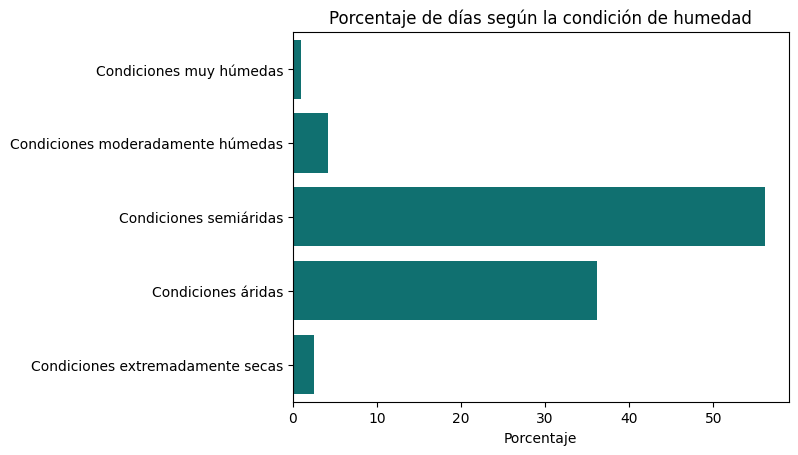

In [59]:
sns.barplot(
    y = "condicion_humedad",
    x = "Porcentaje",
    color = "teal",
    data = datos_humedad
    )

plt.title(
    "Porcentaje de días según la condición de humedad"
)

plt.xlabel("Porcentaje")
plt.ylabel("");

De acuerdo al déficit de presión de vapor al momento que se registró la temperatura máxima, en la zona analizada predominan los días con condiciones semiáridas, seguidas por las condiciones áridas. En contraste, las condiciones moderadamente húmedas, muy húmedas y extremadamente secas presentan una frecuencia considerablemente menor.